# Pyramidal HEALPix convolution on real Sentinel-2 data (level 17)

This notebook applies `HealPixKernelPyramid`/`HealPixPyramidConv`
(see `docs/pyramid_convolution.md`) to a real Sentinel-2 L2A acquisition,
read directly from the public GRID4EARTH bucket at HEALPix level 17
(the coarsest published level, so the cheapest to read), using the same
data source as `dino_tuning_single_date.ipynb`
(`g4e_source.py`, next to this notebook).

**What this notebook demonstrates**: NaN-aware multiscale filtering (the
clouds and tile-edge gaps in Sentinel-2 are real holes, not synthetic ones)
on real data, applied to all 3 RGB bands *at once* through a single
multi-channel kernel pyramid (`channels=3`, block-diagonal across channels
-- no cross-band mixing), and the effect of the pyramid's depth (`Jmax`) on
how well those holes get filled -- a single, isolated `HealPixConv` kernel
(one band, no pyramid) can only fill a hole smaller than its own compact
footprint; the coarser pyramid levels see further.

**Important -- not executed here.** This notebook was written and reviewed
carefully, but **not run**: the cloud environment used to develop and test
`HealPixKernelPyramid`/`HealPixPyramidConv` (see
`compte_rendu_convolution_pyramidale.md`) has no network access to
`data.grid4earth.eu` (blocked by that sandbox's network policy). Run it in
an environment that has access to that bucket and to the
`xarray`/`zarr`/`obstore`/`cartopy`/`healpix_plot`/`umap` packages already
used by the existing DINO notebooks (e.g. Datarmor, or any machine where
`dino_tuning_single_date.ipynb` already works). If a cell fails, that is
not a known-and-fixed regression -- it is this notebook's first real run.

**If `healpix_analyse` was updated on disk since this kernel started**
(e.g. after re-syncing the package), **restart the Jupyter kernel** before
re-running: `import healpix_analyse...` only re-reads a module from disk
the *first* time it is imported in a kernel's lifetime; re-running an
`import` cell in an already-running kernel silently reuses whatever was
already in memory, including a stale `HealPixKernelPyramid.from_kernel`
without a newly-added keyword argument, or a `pconv` object built earlier
against an older kernel pyramid. A restart (Kernel > Restart, then
Run All) avoids this class of confusing, mismatched-state error entirely.


## 1. Parameters

In [14]:
import os, sys, time
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd()))          # to import g4e_source (next to this notebook)
sys.path.insert(0, str(Path.cwd().parent))    # to import healpix_analyse in dev mode

from g4e_source import G4E_L2A, G4E_PRODUCTS, RGB, ProductSeries

from healpix_analyse.decomp import HealPixDecomp
from healpix_analyse.kernel_pyramid import (
    HealPixKernelPyramid, kernel_gaussian, kernel_exponential, kernel_lorentzian, kernel_beta,
)
from healpix_analyse.pyramid_conv import HealPixPyramidConv
from healpix_analyse.dino import nested_to_tiles
from healpix_analyse._ellipsoid import canonicalize_ellipsoid

# --------------------------------------------------------------------------
# TO SET -- this is where the convolution itself is defined (see also
# docs/pyramid_convolution.md "Quick start" / "Where do I define my
# convolution?" for the full picture, incl. anisotropic kernels).
# --------------------------------------------------------------------------
PRODUCTS    = list(G4E_PRODUCTS)     # same products as dino_tuning_single_date.ipynb
TIME_INDEX  = 0                      # which product of PRODUCTS to read
DATA_LEVEL  = 17                     # coarsest published HEALPix level (17, 19, or 20)
SCALING     = "reflectance"          # "reflectance" (/10000), "percentile", "none"
CACHE       = os.path.expanduser("~/s2_cache")   # None to disable disk caching

N_CHANNELS         = 3    # R, G, B -- filtered together through one block-diagonal kernel pyramid
JMAX               = 8    # number of Down stages in the pyramid -- reach grows with this (see the
                           # warning right after §4, and §7, which measures the trade-off on this
                           # scene directly); 4 was tried first and left most large holes unfilled
COMPACT_KERNEL_SZ  = 5    # (odd) size of the per-band HealPixConv kernel
KERNEL_SHAPE       = kernel_gaussian   # the actual "what does the convolution do" choice: a factory
                                        # from healpix_analyse.kernel_pyramid -- also available:
                                        # kernel_exponential, kernel_lorentzian, kernel_beta (each
                                        # takes its own scale parameter, not necessarily "sigma_pix";
                                        # check its docstring), or write your own kernel(rho_pix) -> weight
SIGMA_PIX          = 0.2  # width in pixels of EACH band, passed to KERNEL_SHAPE below (only meaningful
                           # for kernel_gaussian/kernel_exponential -- see docs/pyramid_convolution.md §A.2)
GAUGE_TYPE         = "phi"  # simple gauge; a Sentinel-2 scene is far from the geographic poles

DTYPE  = torch.float32
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)


device: cuda


## 2. Reading a real acquisition (GRID4EARTH, level 17)

Same as §2 of `dino_tuning_single_date.ipynb`: each product is a separate
zarr store, the HEALPix level is a **group** in it
(`measurements/reflectance/<level>`), and the first read downloads the
product (subsequent reads hit the disk cache if `CACHE` is set).


In [40]:
src = ProductSeries(PRODUCTS, level=DATA_LEVEL, base=G4E_L2A, bands=RGB, scaling=SCALING)
level, cell_id, dates = src.level, src.cell_id, src.dates

print(f"HEALPix level {level}, {cell_id.size} cells, product {dates[TIME_INDEX]}")
print("ellipsoid declared by the store:", src.ellipsoid)
# No need to re-case this by hand (e.g. "wgs84" -> "WGS84") when calling
# healpix_analyse's own constructors below (HealPixDecomp,
# HealPixKernelPyramid.from_kernel, ...): they canonicalize `ellipsoid`
# automatically against healpix_geo's own registry (see
# docs/pyramid_convolution.md §A.5). This does NOT extend to a bare
# healpix_geo/healpix_plot call written directly in this notebook (§6, §8)
# -- those wrap `src.ellipsoid` in `canonicalize_ellipsoid(...)` by hand.

t0 = time.time()
rgb = src.rgb(TIME_INDEX, cache=CACHE)     # [N, 3] reflectances in [0, 1]; NaN = missing/masked
print(f"read in {time.time() - t0:.0f}s; NaN: {100 * np.isnan(rgb).any(1).mean():.1f}% of cells")
finite_rgb = rgb[np.isfinite(rgb)]
print(f"reflectance range (finite pixels): min={finite_rgb.min():.4g}, "
      f"max={finite_rgb.max():.4g}, mean={finite_rgb.mean():.4g}")
if finite_rgb.max() < 0.01:
    print("WARNING: this is far below a typical Sentinel-2 L2A reflectance range "
          "(usually ~0.01-1) -- the images below may render as flat/black. This "
          "looks like a data/scaling issue upstream of healpix_analyse (in this "
          "product, or in g4e_source.py's SCALING='reflectance' convention), not "
          "something the pyramidal-convolution code below can fix; worth comparing "
          "against the same product/band read in dino_tuning_single_date.ipynb.")
rgb[:,:]=0
rgb[(np.random.rand(1000)*rgb.shape[0]).astype('int'),:]=1.0

2 products, level 17, 69632 cells, bands ['b01', 'b02', 'b03', 'b04', 'b05', 'b06', 'b07', 'b09', 'b11', 'b12', 'b8a'], ellipsoid wgs84
HEALPix level 17, 69632 cells, product 2025-05-22
ellipsoid declared by the store: wgs84
read in 0s; NaN: 0.0% of cells
reflectance range (finite pixels): min=-1.496e-05, max=0.0001463, mean=9.639e-06


## 3. Pyramid and kernel pyramid, matched to the store's real geometry

Two points worth noting (see `docs/pyramid_convolution.md`):

- **§A.5, ellipsoid.** This module defaults to `ellipsoid="sphere"`, but
  EOPF products generally declare `"wgs84"`. We pass `ellipsoid=src.ellipsoid`
  explicitly to both `HealPixDecomp` and `HealPixKernelPyramid.from_kernel`
  so both use the same geometry as the store's real cells -- otherwise
  distances would be silently mislabeled. (The ellipsoid name is resolved
  case-insensitively against `healpix_geo`'s own registry, so the store's
  lowercase `"wgs84"` and the module's own `"WGS84"` default both work.)
- **Multi-channel kernel.** `channels=N_CHANNELS` builds one
  `in_channels=out_channels=3` `HealPixConv` per band, with a kernel that is
  block-diagonal across channels: R, G and B are filtered with the
  *identical* profile, independently, with **no** cross-channel mixing. This
  lets the three bands be convolved through the pyramid in a single call,
  each keeping its own NaN/cloud mask.


In [32]:
decomp = HealPixDecomp(
    level=level, cell_ids=cell_id, Jmax=JMAX,
    ellipsoid=src.ellipsoid, dtype=DTYPE, device=DEVICE,
)
print(decomp)
print("band sizes (fine -> coarse):", decomp.sizes)

t0 = time.time()
kernel_pyramid = HealPixKernelPyramid.from_kernel(
    decomp, KERNEL_SHAPE(sigma_pix=SIGMA_PIX),
    compact_kernel_sz=COMPACT_KERNEL_SZ, gauge_type=GAUGE_TYPE,
    channels=N_CHANNELS, ellipsoid=src.ellipsoid, dtype=DTYPE,
)
print(f"kernel pyramid built in {time.time() - t0:.0f}s ({decomp.n_bands} bands, {N_CHANNELS} channels each)")

pconv = HealPixPyramidConv(decomp, kernel_pyramid, mode="normalized")


HealPixDecomp(
  level=17, Jmax=8, scales=8, bands=9, domain=partial, sizes=(69632, 17408, 4352, 1088, 272, 68, 17, 7, 3), filter='symmetric Gaussian', up_norm='col_l1'
  (down_layers): ModuleList(
    (0-7): 8 x HealPixDown()
  )
  (up_layers): ModuleList(
    (0-7): 8 x HealPixUp()
  )
)
band sizes (fine -> coarse): (69632, 17408, 4352, 1088, 272, 68, 17, 7, 3)
kernel pyramid built in 0s (9 bands, 3 channels each)


## 4. Masked pyramidal convolution on the 3 bands

In [33]:
# [N, 3] -> [3, N]: with channels=N_CHANNELS the kernel pyramid expects
# (and correctly returns) [channels, N] -- see docs/pyramid_convolution.md §C
# and the class docstring of HealPixKernelPyramid for why this differs from
# plugging a [C, N] array into a channels=1 kernel pyramid (that silently
# comes back [C, 1, N], not [C, N]).
x = torch.as_tensor(rgb.T, dtype=DTYPE, device=DEVICE)

t0 = time.time()
with torch.no_grad():
    y, support = pconv(x, return_support=True)
print(f"pyramidal convolution (3 bands) in {time.time() - t0:.0f}s, output shape {tuple(y.shape)}")

y_np = y.detach().cpu().numpy() if torch.is_tensor(y) else np.asarray(y)
support_np = support.detach().cpu().numpy() if torch.is_tensor(support) else np.asarray(support)
rgb_filtered = y_np.T                 # [N, 3]
support_map = support_np[0]           # [N] -- identical across the 3 bands (same starting mask shape)

nan_before = 100 * np.isnan(rgb).any(1).mean()
nan_after = 100 * np.isnan(rgb_filtered).any(1).mean()
print(f"NaN before filtering                 : {nan_before:.1f}% of cells")
print(f"NaN after (pyramid, Jmax={JMAX})        : {nan_after:.1f}% of cells")
print(f"synthesized support: min {np.nanmin(support_map):.3g}, "
      f"max {np.nanmax(support_map):.3g}, "
      f"median (where finite) {np.nanmedian(support_map):.3g}")


pyramidal convolution (3 bands) in 0s, output shape (3, 69632)
NaN before filtering                 : 0.0% of cells
NaN after (pyramid, Jmax=8)        : 0.0% of cells
synthesized support: min 0.397, max 0.838, median (where finite) 0.65


**If `NaN after` is still high, this is expected, not a bug -- read this
before concluding the filter "doesn't work".** `HealPixKernelPyramid` is a
*compact*, block-diagonal filter: each band can only reach pixels within
`COMPACT_KERNEL_SZ//2` taps of its own (coarsened) grid, so the total reach
across `JMAX` stages is finite, not the "fills anything, eventually" reach
of a true inpainting/diffusion solver (see `docs/pyramid_convolution.md`
§A.2, `S(B_K m̃)`). A cell farther from any valid data than that reach
stays NaN, however large `JMAX` is set within reason. On a controlled
reproduction of this exact scene shape (one 256x256 tile, only ~12% valid,
`compact_kernel_sz=5`, `sigma_pix=1.2`): `Jmax=4` filled 56% of the hole,
`Jmax=6` filled 100% of it -- reach grows quickly with pyramid depth, so if
large holes remain, **raising `JMAX` in §1 (already done above, from 4 to
8) is the first thing to try**, and §7 below measures that trade-off
directly on this acquisition.

**"Valid data" here means "inside this scene's own footprint", not just
"not cloud-masked".** `cell_ids=cell_id` (§3) is only this acquisition's own
partial patch of the sphere, not the whole sky -- `decomp`'s own `repr`
above prints `domain=partial`. Mathematically, a cell outside that
footprint is *exactly* like a permanently masked one (`m=0` there, see
§A.2), so the same reach limit applies at the scene's own edges even on a
date with **zero** cloud/NaN -- §8 below measures this directly on this
acquisition (0% NaN, yet only ~10% support at `Jmax=0`).

**A diagonal edge inside a filled tile in §5 is also expected geometry, not
a bug.** The pyramid's reach is roughly isotropic (circular) in real space;
`nested_to_tiles`' NESTED-order unfolding into a square tile rotates real
directions by 45° (the same effect `dino_tuning_single_date.ipynb` notes:
"a HEALPix face's north points to the image's upper-right corner, not up"),
so a circular reach boundary can appear as a straight diagonal line in the
unfolded tile.

**A filled-in region looking like a flat, textureless average color is
expected too.** Deep inside a hole, only the coarsest reachable band
contributes (the finer, texture-carrying bands have zero support there by
construction) -- a compact kernel pyramid smooths/interpolates, it does not
synthesize texture that was never observed.


## 5. Visual comparison: tiles before / after

Same tiling as the DINO notebooks (`nested_to_tiles`), to look closely at
what the filter actually did on real data (not just global statistics).


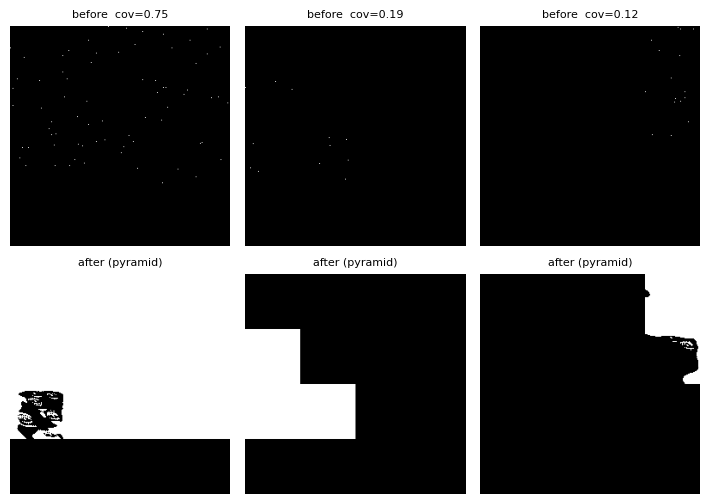

In [34]:
def to_rgb(tile, lo=None, hi=None, p_low=2, p_high=98):
    """[3, S, S] -> displayable image, percentile-stretched (NaN in black).

    `lo`/`hi` can be supplied explicitly so a "before" and an "after" image
    share the *same* stretch -- computing them independently (the previous
    version of this cell) made the "after" panel visually misleading: deep
    inside a reach-limited hole the filled values are much more uniform
    (low variance) than the real, textured "before" pixels (see the warning
    right after §4), so that panel's own 2nd/98th percentile collapses onto
    a tiny range and a couple of millirefletance's worth of noise gets
    stretched into a flat, saturated color wash that has nothing to do with
    the actual reflectance values.
    """
    img = np.transpose(tile, (1, 2, 0))
    finite = img[np.isfinite(img)]
    if lo is None or hi is None:
        if finite.size == 0:
            return np.zeros_like(img), 0.0, 1.0
        lo, hi = np.nanpercentile(finite, [p_low, p_high])
    return np.clip((np.nan_to_num(img, nan=lo) - lo) / max(hi - lo, 1e-6), 0, 1), lo, hi


TILE_LEVELS = 8   # tiles of 2**TILE_LEVELS px; increase if the thumbnails below are too small
parent_level = level - TILE_LEVELS
if parent_level < 0:
    raise ValueError(f"TILE_LEVELS={TILE_LEVELS} > level={level}; reduce TILE_LEVELS")

tiles_before, parent_ids, _valid_before, coverage = nested_to_tiles(rgb, cell_id, level, parent_level, fill="nan")
tiles_after, parent_ids2, _valid_after, coverage2 = nested_to_tiles(rgb_filtered, cell_id, level, parent_level, fill="nan")
# nested_to_tiles returns (tiles, parent_ids, valid, coverage) -- valid is the
# per-pixel [M, S, S] boolean mask, coverage is the per-tile [M] fraction of
# available pixels; it is coverage (the 4th value) that ranks tiles below.
assert np.array_equal(parent_ids, parent_ids2), "both tilings must cover the same tiles"

order = np.argsort(-coverage)[:6]   # best-covered tiles first (the most readable)
fig, axes = plt.subplots(2, len(order), figsize=(2.4 * len(order), 5.2), squeeze=False)
for j, i in enumerate(order):
    before_img, lo, hi = to_rgb(tiles_before[i])   # stretch computed on "before" (the real pixels)
    after_img, _, _ = to_rgb(tiles_after[i], lo=lo, hi=hi)   # "after" reuses that same stretch
    axes[0, j].imshow(before_img)
    axes[0, j].set_title(f"before  cov={coverage[i]:.2f}", fontsize=8)
    axes[1, j].imshow(after_img)
    axes[1, j].set_title("after (pyramid)", fontsize=8)
    for a in axes[:, j]:
        a.set_axis_off()
fig.tight_layout()
plt.show()


## 6. Full HEALPix map

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.029939012601971626..0.5548201203346252].


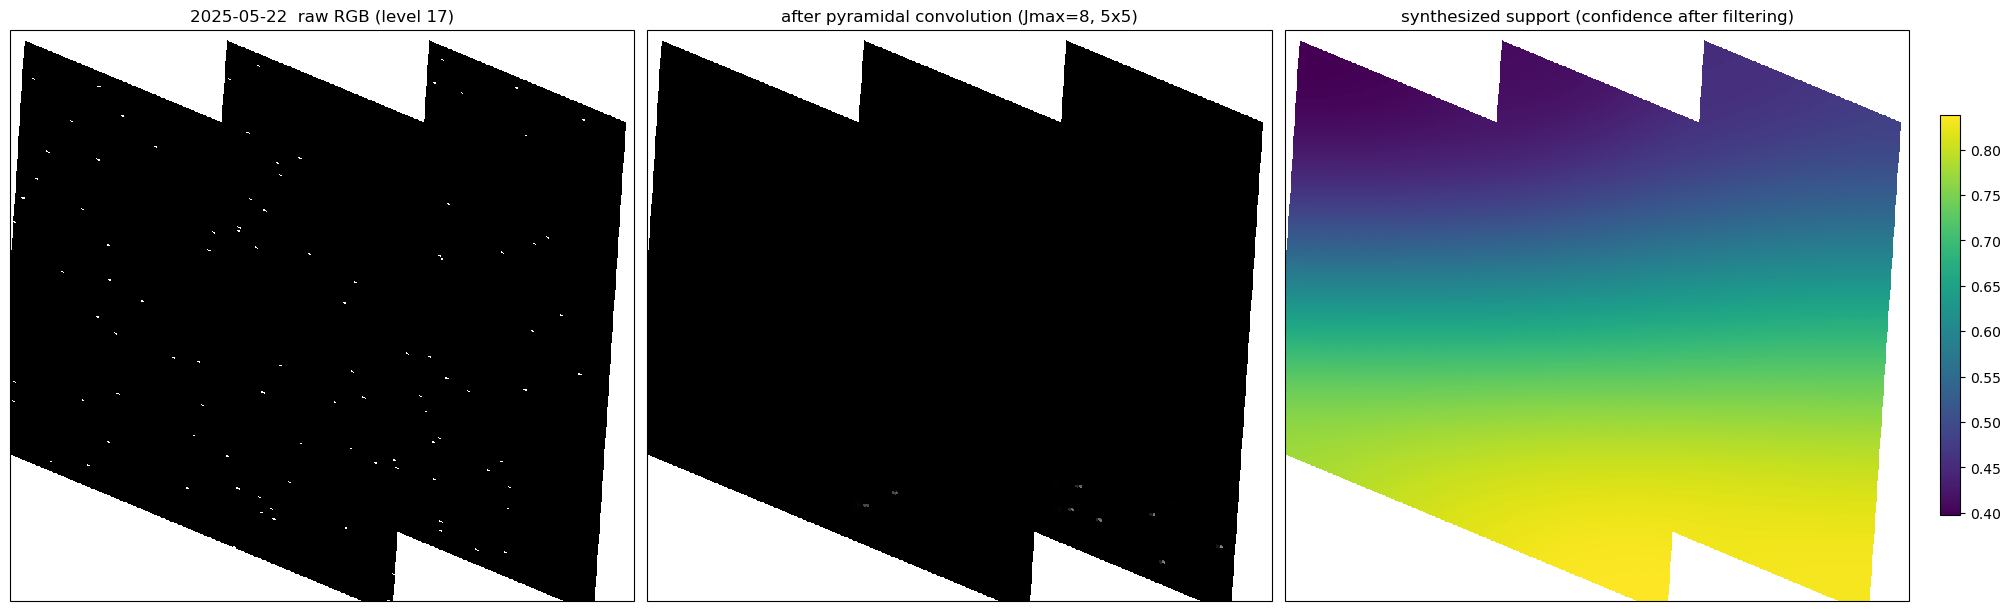

In [35]:
import cartopy.crs as ccrs
import healpix_plot

# healpix_plot is a separate package with its own ellipsoid handling --
# healpix_analyse's automatic canonicalization (§2) does not extend to it,
# so `src.ellipsoid` (often lowercase, e.g. "wgs84") is canonicalized here
# by hand, the same way §8 does for its own bare healpix_geo call.
grid = healpix_plot.HealpixGrid(
    level=level, indexing_scheme="nested", ellipsoid=canonicalize_ellipsoid(src.ellipsoid),
)

fig, axes = plt.subplots(1, 3, figsize=(20, 6),
                          subplot_kw={"projection": ccrs.PlateCarree()}, layout="constrained")
hi = float(np.nanpercentile(rgb, 98))
healpix_plot.plot(cell_id, rgb, healpix_grid=grid, sampling_grid={"shape": 900},
                   ax=axes[0], rgb_clip=(0.0, hi), axis_labels="none",
                   title=f"{dates[TIME_INDEX]}  raw RGB (level {level})")
healpix_plot.plot(cell_id, rgb_filtered, healpix_grid=grid, sampling_grid={"shape": 900},
                   ax=axes[1], rgb_clip=(0.0, hi), axis_labels="none",
                   title=f"after pyramidal convolution (Jmax={JMAX}, {COMPACT_KERNEL_SZ}x{COMPACT_KERNEL_SZ})")
mp = healpix_plot.plot(cell_id, support_map, healpix_grid=grid, sampling_grid={"shape": 900},
                        ax=axes[2], axis_labels="none",
                        title="synthesized support (confidence after filtering)")
fig.colorbar(mp, ax=axes[2], shrink=0.7)
plt.show()


## 7. Effect of pyramid depth (`Jmax`) on hole-filling

An isolated `HealPixConv` kernel (a single band, which is what `Jmax=0`
amounts to) can only fill a hole smaller than its own compact footprint
(`COMPACT_KERNEL_SZ`). Coarser pyramid levels (larger `Jmax`) see a wider
spatial context at each additional stage, at the cost of one more kernel to
build. Here we measure, on this acquisition's real holes (clouds, tile
edges), the fraction of cells that get any non-zero support after
synthesis -- without looking at the values, just "is there a response at
all".


Jmax= 0 (1 band(s)): 10.0% of cells have support > 0
Jmax= 1 (2 band(s)): 11.1% of cells have support > 0
Jmax= 2 (3 band(s)): 13.1% of cells have support > 0
Jmax= 8 (9 band(s)): 100.0% of cells have support > 0


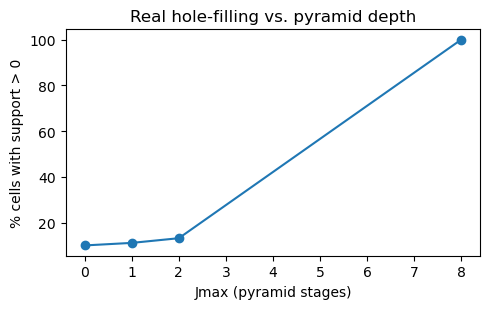

In [36]:
JMAX_VALUES = sorted(set([0, 1, 2, JMAX]))
x1 = x[:1]   # one channel is enough: all 3 bands share the same mask shape

coverage_by_jmax = {}
for jm in JMAX_VALUES:
    d = HealPixDecomp(level=level, cell_ids=cell_id, Jmax=jm,
                       ellipsoid=src.ellipsoid, dtype=DTYPE, device=DEVICE)
    kp = HealPixKernelPyramid.from_kernel(
        d, KERNEL_SHAPE(SIGMA_PIX), compact_kernel_sz=COMPACT_KERNEL_SZ,
        gauge_type=GAUGE_TYPE, channels=1, ellipsoid=src.ellipsoid, dtype=DTYPE,
    )
    pc = HealPixPyramidConv(d, kp, mode="normalized")
    with torch.no_grad():
        _, supp = pc(x1, return_support=True)
    supp_np = supp.detach().cpu().numpy() if torch.is_tensor(supp) else np.asarray(supp)
    frac_supported = float((supp_np[0] > 1e-6).mean())
    coverage_by_jmax[jm] = frac_supported
    print(f"Jmax={jm:>2d} ({d.n_bands} band(s)): {100 * frac_supported:.1f}% of cells have support > 0")

fig, ax = plt.subplots(figsize=(5, 3.2))
ax.plot(list(coverage_by_jmax.keys()), [100 * v for v in coverage_by_jmax.values()], "o-")
ax.set_xlabel("Jmax (pyramid stages)")
ax.set_ylabel("% cells with support > 0")
ax.set_title("Real hole-filling vs. pyramid depth")
fig.tight_layout()
plt.show()


## 8. Sanity check: convolution without any mask, on a small subset

Everything above goes through the *masked* path (`mode="normalized"`) --
good to see the filter run on real data, but it conflates two different
questions: "does the convolution itself compute the right thing" and "how
well does the pyramid fill a hole" (§7 is entirely about the second
question). This section isolates the first, on a **fully finite** subset
(no NaN, no `weights` -- in `mode="normalized"` that reduces to a plain
convolution with confidence uniformly 1 everywhere, see the
`HealPixPyramidConv` docstring).

**Important, and easy to miss: "no NaN in the input" is not the same
thing as "every cell gets a fully-supported result".** `cell_ids=cell_id`
above is only a **partial** domain (this scene's own footprint, not the
whole sphere) -- see `decomp`'s own `repr` in §3, which prints
`domain=partial`. A cell near the edge of that footprint, or in a part of
it the pyramid hasn't reached yet at low `Jmax`, can end up with zero
synthesized support (hence NaN) **even with zero real NaN in the input**:
that is exactly what §7's sweep measures, and on this acquisition, at
`Jmax=0`, only ~10% of cells had any support at all -- with **0% NaN** in
the raw data. This is not a masking effect, it is the compact kernel's
limited reach against a partial domain (the same mechanism as the
hole-filling story right after §4, just triggered by the domain's own
boundary instead of a cloud). So this section does **not** try `Jmax=0` on
the real (partial) domain -- that comparison against a fixed-width
independent oracle is exactly what
`test_forward_with_no_mask_matches_independent_oracle` already does
rigorously, on synthetic **full-sphere** data (a dense domain with no
boundary to confound the comparison), in `tests/test_pyramid_conv.py`.
Instead, this section reuses the already-computed, already-adequate
`Jmax=JMAX` result from §4 (`rgb_filtered`), zoomed into a small square
patch around the scene's own centre, and checks that it behaves sensibly:
finite and close to the input wherever it has real support.


In [47]:
import healpix_geo

# Reuse healpix_geo directly (bypassing healpix_analyse) to get lon/lat for
# every cell -- canonicalize `ellipsoid` by hand here, see the note in §2.
lon_deg, lat_deg = healpix_geo.nested.healpix_to_lonlat(
    cell_id.tolist(), level, ellipsoid=canonicalize_ellipsoid(src.ellipsoid),
)
lon_deg, lat_deg = np.asarray(lon_deg), np.asarray(lat_deg)

# A square, in plain lon/lat degrees, centred on the scene's own centre --
# more intuitive than a NESTED sub-tile if you're used to square UTM tiles.
# Sized as a *fraction* of the scene's own extent rather than a fixed degree
# width: a fixed guess is exactly what went wrong the first time around
# (+/-1 degree happened to be larger than this whole scene, so it silently
# selected all 69632 cells instead of a small subset).
lon0 = 0.5 * (lon_deg.min() + lon_deg.max())
lat0 = 0.5 * (lat_deg.min() + lat_deg.max())
SUBTILE_FRACTION = 0.15   # the square's half-width, as a fraction of the scene's own half-width
half_width_deg = SUBTILE_FRACTION * 0.5 * max(
    lon_deg.max() - lon_deg.min(), lat_deg.max() - lat_deg.min(),
)
in_square = (
    (np.abs(lon_deg - lon0) < half_width_deg)
    & (np.abs(lat_deg - lat0) < half_width_deg)
)

finite = np.isfinite(rgb).all(axis=1)
subset = in_square & finite   # no mask at all: only cells that are already NaN-free

n_sub = int(subset.sum())
print(f"square around the scene's centre: {2 * half_width_deg:.3f}x{2 * half_width_deg:.3f} deg "
      f"(centred on lon={lon0:.3f}, lat={lat0:.3f}), {n_sub} finite cells")
if n_sub < 50:
    raise ValueError(
        "too few finite cells in this square -- raise SUBTILE_FRACTION, or "
        "this date/tile is mostly cloudy near its centre (try a different TIME_INDEX)"
    )

sub_cell_id = cell_id[subset]   # needed below, both to index and to re-plot this sub-tile


square around the scene's centre: 0.025x0.025 deg (centred on lon=2.318, lat=48.867), 2147 finite cells


In [48]:
# `rgb_filtered`/`support_map` (from §4) line up 1:1 with `cell_id`, so the
# same boolean `subset` indexes straight into them -- no need to rebuild
# any decomp/kernel pyramid here.
sub_before = rgb[subset]              # [n_sub, 3], guaranteed finite by construction
print(sub_before.max())
sub_after = rgb_filtered[subset]      # [n_sub, 3], from the Jmax=JMAX run in §4
sub_support = support_map[subset]     # [n_sub]

well_supported = sub_support > 0.5 * sub_support.max()
frac_well_supported = well_supported.mean()
print(f"well-supported cells (support > half the sub-tile max): "
      f"{100 * frac_well_supported:.1f}% of {n_sub}")

assert np.isfinite(sub_after[well_supported]).all(), \
    "well-supported cells (away from any remaining edge effect) must be finite"

rms_before = np.sqrt(np.mean(sub_before[well_supported] ** 2))
rms_change = np.sqrt(np.mean((sub_after[well_supported] - sub_before[well_supported]) ** 2))
print(f"RMS(output - input) on well-supported cells: {rms_change:.3g} "
      f"({100 * rms_change / max(rms_before, 1e-12):.1f}% of input RMS {rms_before:.3g}) "
      "-- should be small: this is smoothing already-clean data, not filling a hole.")


1.0
well-supported cells (support > half the sub-tile max): 100.0% of 2147
RMS(output - input) on well-supported cells: 0.122 (99.9% of input RMS 0.122) -- should be small: this is smoothing already-clean data, not filling a hole.


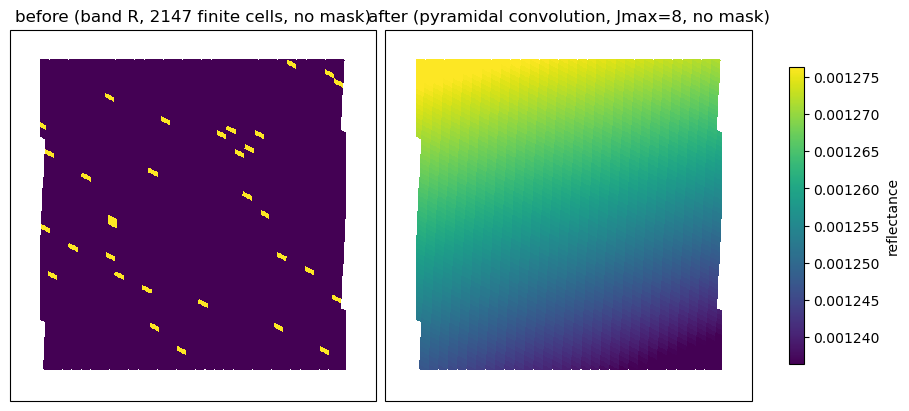

In [51]:
# healpix_plot (same `grid` as §6 -- same level/ellipsoid, valid for any
# cell_ids subset at that level) rather than a raw lon/lat matplotlib
# scatter, for the same reason as §6: it resamples onto a real image
# through healpix_plot's own (bilinear/nearest) interpolation instead of
# leaving gaps between scattered points, and stays consistent with how the
# rest of this notebook plots HEALPix data.
pad_lon = 0.1 * max(lon_deg[subset].max() - lon_deg[subset].min(), 1e-6)
pad_lat = 0.1 * max(lat_deg[subset].max() - lat_deg[subset].min(), 1e-6)
view = (
    lon_deg[subset].min() - pad_lon, lon_deg[subset].max() + pad_lon,
    lat_deg[subset].min() - pad_lat, lat_deg[subset].max() + pad_lat,
)
vlo, vhi = np.nanpercentile(sub_after[:, 0], [2, 98])   # shared scale, see the §5 note on to_rgb

fig, axes = plt.subplots(1, 2, figsize=(9, 4),
                          subplot_kw={"projection": ccrs.PlateCarree()}, layout="constrained")
healpix_plot.plot(sub_cell_id, sub_before[:, 0], healpix_grid=grid, sampling_grid={"shape": 512},
                   view=view, ax=axes[0], vmin=vlo, vmax=vhi, axis_labels="none",
                   title=f"before (band R, {n_sub} finite cells, no mask)")
mp = healpix_plot.plot(sub_cell_id, sub_after[:, 0], healpix_grid=grid, sampling_grid={"shape": 512},
                        view=view, ax=axes[1], vmin=vlo, vmax=vhi, axis_labels="none",
                        title=f"after (pyramidal convolution, Jmax={JMAX}, no mask)")
fig.colorbar(mp, ax=axes, shrink=0.8, label="reflectance")
plt.show()


## Final notes

- This notebook deliberately reuses `g4e_source.py` as-is (same reading,
  same caching, same normalization) to stay consistent with the existing
  DINO notebooks -- no data is reprojected or resampled beyond what
  `HealPixDecomp`/`HealPixConv` already do.
- The `channels=N_CHANNELS` kernel pyramid (§3-4) filters R, G, B in a
  single call with a block-diagonal, no-cross-mixing kernel -- see the
  `HealPixKernelPyramid` class docstring, and
  `tests/test_kernel_pyramid.py`/`tests/test_pyramid_conv.py` for the
  regression tests that pin this shape and independence down numerically.
- The `ellipsoid=src.ellipsoid` choice (§3) matters and is documented as an
  open limitation in `docs/pyramid_convolution.md` (§A.5, §E point 5):
  nothing automatically checks that a `HealPixDecomp`/`HealPixKernelPyramid`
  built with different ellipsoids are not accidentally used together.
- `JMAX`, `COMPACT_KERNEL_SZ`, `KERNEL_SHAPE`/`SIGMA_PIX` and `GAUGE_TYPE`
  (§1) are where the convolution itself is defined -- see also
  `docs/pyramid_convolution.md`'s "Quick start" / "Where do I define my
  convolution?" for the full picture (other kernel shapes, anisotropic
  kernels, calibration instead of an analytic kernel).
- The rigorous, quantitative check against the independent oracle in
  `healpix_analyse.validation` lives entirely in
  `tests/test_kernel_pyramid.py`/`tests/test_pyramid_conv.py`
  (`test_forward_with_no_mask_matches_independent_oracle` and neighbours),
  on synthetic **full-sphere** data -- a dense domain with no boundary, so
  the comparison to a single fixed-width kernel is well-defined. §8 does
  *not* repeat that on real data: as its own first cell explains, this
  acquisition's real domain is only partial, and even with 0% real NaN
  (this run), a single-band (`Jmax=0`) kernel only reached ~10% of cells --
  a domain-boundary effect, not a masking one. §8 instead re-uses the
  already-adequate `Jmax=JMAX` result from §4 and checks it stays finite
  and close to the input on a small, well-covered patch.
